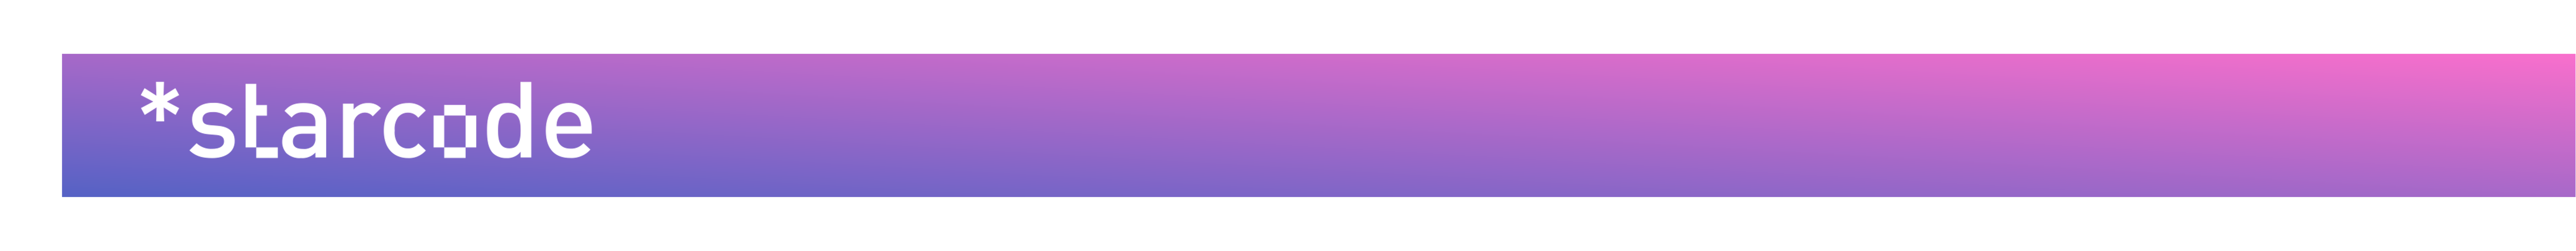



# **<span style="color: #6162C5;">Künstliche Intelligenz mit Python</span>  <span style="color: #7865C6;"> - Woche 6: Regression </span>** &nbsp;

[![Binder](https://mybinder.org/badge_logo.svg)]()

#### TODO: add binder link

Willkommen in der achten Woche des Kurses 'Künstliche Intelligenz mit Python'. Nachdem wir uns letzte Woche damit beschäftigt haben, was hinter dem Begriff KI steckt und uns ein erstes Beispiel angeschaut haben, in welchem wir ein neuronales Netzwerk verwendet haben, um handgeschriebene Zahlen zu erkennen, wollen wir uns in dieser Woche mit zwei neuen Begriffen beschäftigen: *Regression*. Diese Konzepte bilden nämlich die Grundlage der meisten Probleme, auf die künstliche Intelligenz angewendet werden kann.

In der *Regression* wird angestrebt, Zusammenhänge zwischen unterschiedlichen Variablen zu identifizieren und durch die Analyse dieser Beziehungen zukünftige Vorhersagen zu treffen. Dabei erstellt der Computer Modelle, um Muster in Daten zu finden und dann genaue Vorhersagen für Zahlen zu machen.  Ein anschauliches Beispiel hierfür ist die Prognose des Verkehrsaufkommens mithilfe historischer Verkehrsdaten. Wenn der Computer diese Daten analysiert, kann er nicht nur Muster im täglichen Verkehrsaufkommen identifizieren, sondern auch Faktoren wie Wetterbedingungen, Veranstaltungen oder Baustellen berücksichtigen. Auf dieser Grundlage kann das Modell dann Vorhersagen darüber treffen, wie stark der Verkehr zu bestimmten Zeiten in der Zukunft sein wird.

In dieser und in den nächsten Wochen werden wir die Bibliothek Scikit-learn verwenden. Sie ermöglicht es, verschiedene Machine-Learning-Modelle einfach zu erstellen, zu trainieren und zu verwenden, und ist daher besonders für Einsteiger geeignet. Wie in den Wochen zuvor verwenden wir auch noch zusätzlich NumPy und Matplotlib:

In [ ]:
! pip install numpy matplotlib scikit-learn

## <span style="color: #9C68C8;">Lineare Regression</span>

Im Rahmen eures Mathematikunterrichts habt ihr bestimmt schon einmal die *lineare Funktion* kennengelernt. Diese lässt sich wie folgt darstellen:
$$
f(x) = m\cdot x + c
$$

wobei der Parameter $m$ die Steigung der Geraden, und der Parameter $c$ der y-Achsenschnittpunkt ist. Genauso kennt ihr vielleicht auch schon quadratische Funktionen $f(x)=x^2$, kubische Funktionen $f(x)=x^3$, usw. Wenn wir jetzt einen Datensatz haben, in dem wir wissen, welcher Zusammenhang, also welche Funktion dahinter steckt, aber nicht wissen, welche Werte die Parameter (z.b. $m$ und $c$) einnehmen, dann können wir *lineare Regression* verwenden.

Der Begriff *lineare Regression* kann ein bisschen irreführend sein. Diese Methode kann nämlich nicht nur auf *lineare* Funktionen angewendet werden. Vielmehr steht hier das *linear* für die Linearität der Koeffizienten oder Zahlen, die wir verwenden, um Beziehungen zwischen verschiedenen Dingen zu beschreiben. Auch wenn die Beziehung zwischen den Dingen wie eine Kurve aussieht (wie bei einer kubischen oder quadratischen Funktionen), sind die Zahlen, die wir benutzen, immer noch auf einfache Weise miteinander verbunden, und deshalb nennen wir es '*linear*'.

Der erste Schritt in der Anwendung der Linearen ist es also, den Zusammenhang zwischen den Daten zu erkennen. Schauen wir uns das ganze mal an einem Beispiel an!

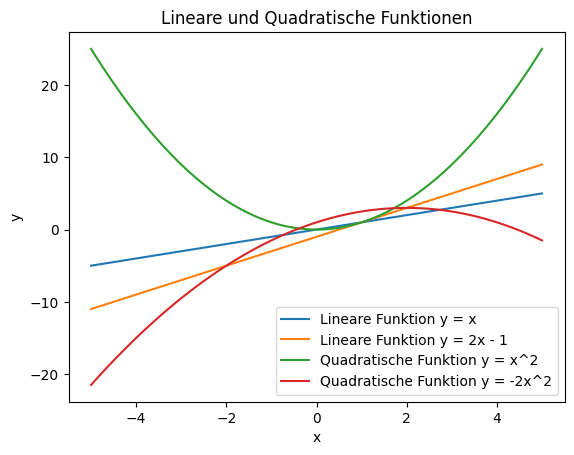

In [ ]:
# Hier ist ein Beispiel für die Plots von linearen, quadratischen und kubischen Funktionen
# Du kanst den Code nicht verstehen

import matplotlib.pyplot as plt
import numpy as np

# Generiere x-Werte
x = np.linspace(-5, 5, 100)

# Definiere Funktionen
def lineare_funktion(x, m, c):
    return m * x + c

def quadratische_funktion(x, a, b, c):
    return a * x**2 + b * x + c

# Plot für lineare Funktionen
plt.plot(x, lineare_funktion(x, 1, 0), label="Lineare Funktion y = x")
plt.plot(x, lineare_funktion(x, 2, -1), label="Lineare Funktion y = 2x - 1")

# Plot für quadratische Funktionen
plt.plot(x, quadratische_funktion(x, 1, 0, 0), label="Quadratische Funktion y = x^2")
plt.plot(x, quadratische_funktion(x, -0.5, 2, 1), label="Quadratische Funktion y = -2x^2")

# Diagramm anpassen
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lineare und Quadratische Funktionen")
plt.legend()
plt.show()


## Aufgabe 6.1 Wachstumsrate von Pflanzen vorhersagen




*Vorhersage der Wachstumsrate einer Pflanze (z. B. Zunahme der Höhe oder Biomasse pro Woche) basierend auf der Effizienz der Photosynthese unter kontrollierten Bedingungen.*

Die Erforschung des Pflanzenwachstums und der Photosynthese hat Wissenschaftlerinnen und Wissenschaftler seit Jahrhunderten beschäftigt. Eine herausragende Persönlichkeit in diesem Bereich war [Katherine Esau](https://de.wikipedia.org/wiki/Katherine_Esau).

Esaus bahnbrechende Arbeit in der Pflanzenanatomie revolutionierte unser Verständnis darüber, wie Pflanzen wachsen und Nährstoffe transportieren. Geboren im Jahr 1898, überwand sie enorme Herausforderungen, darunter die Flucht vor politischer Unruhe in Russland, um ihrer Leidenschaft für die Wissenschaft zu folgen. Ihre akribischen Forschungen brachten ihr weltweite Anerkennung, und ihre Lehrbücher wurden zu Grundlagenwerken der Botanik. 1989 erhielt sie die National Medal of Science, eine der höchsten wissenschaftlichen Ehrungen der USA, in Anerkennung ihrer lebenslangen Hingabe an die Geheimnisse des Pflanzenlebens.

Ihre Geschichte ist eine inspirierende Erzählung von Resilienz, Neugier und unermüdlichem Engagement für die Wissenschaft und zeigt, wie ein tieferes Verständnis der Pflanzenbiologie auch praktische Anwendungen - wie die Vorhersage des Pflanzenwachstums - fördern kann.


### Aufgabe 6.1.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Important Note: the data is syntetic
plants_data = [
    ["Wheat", 0.4, 1.5],
    ["Corn", 0.7, 3.2],
    ["Rice", 0.5, 2.0],
    ["Soybean", 0.3, 1.0],
    ["Barley", 0.4, 1.6],
    ["Sorghum", 0.6, 2.8],
    ["Oats", 0.4, 1.4],
    ["Millet", 0.5, 2.1],
    ["Sugarcane", 0.8, 3.5],
    ["Cassava", 0.5, 1.8],
    ["Potato", 0.4, 1.2],
    ["Sunflower", 0.6, 2.5],
    ["Peanut", 0.4, 1.3],
    ["Alfalfa", 0.5, 1.9],
    ["Tomato", 0.5, 2.3],
    ["Cabbage", 0.4, 1.7],
    ["Lettuce", 0.3, 1.2],
    ["Maize", 0.7, 3.1],
    ["Cucumber", 0.6, 2.6],
    ["Carrot", 0.4, 1.5],
]
# Extracting x and y values from the plants_data
x = np.array([plant[1] for plant in plants_data])
y = np.array([plant[2] for plant in plants_data])

In [ ]:
# Vizualiziere Daten mit plotlib
# Hint: Benutze plt.plot
<Dein Code hier>

### Aufgabe 6.1.2
*Uberlege dir dann gemeinsam in der Gruppe, welche Funktion denn die Daten am besten beschreibt (linear, quadratisch, kubisch ...)?*


\<Dein antwort hier\>

### Aufgabe 6.1.3 <span style="color: #C26BCA;"> Fehlerbestimmung </span>

Um zu quantifizieren, wie gut unsere Linie die Daten beschreibt, können wir uns den Abstand zwischen unseren Datenpunkten $Y(x)$ und dem Wert der Linie an der gleichen Stelle $f(x)$ anschauen:
$$
|Y(x)-f(x)|.
$$
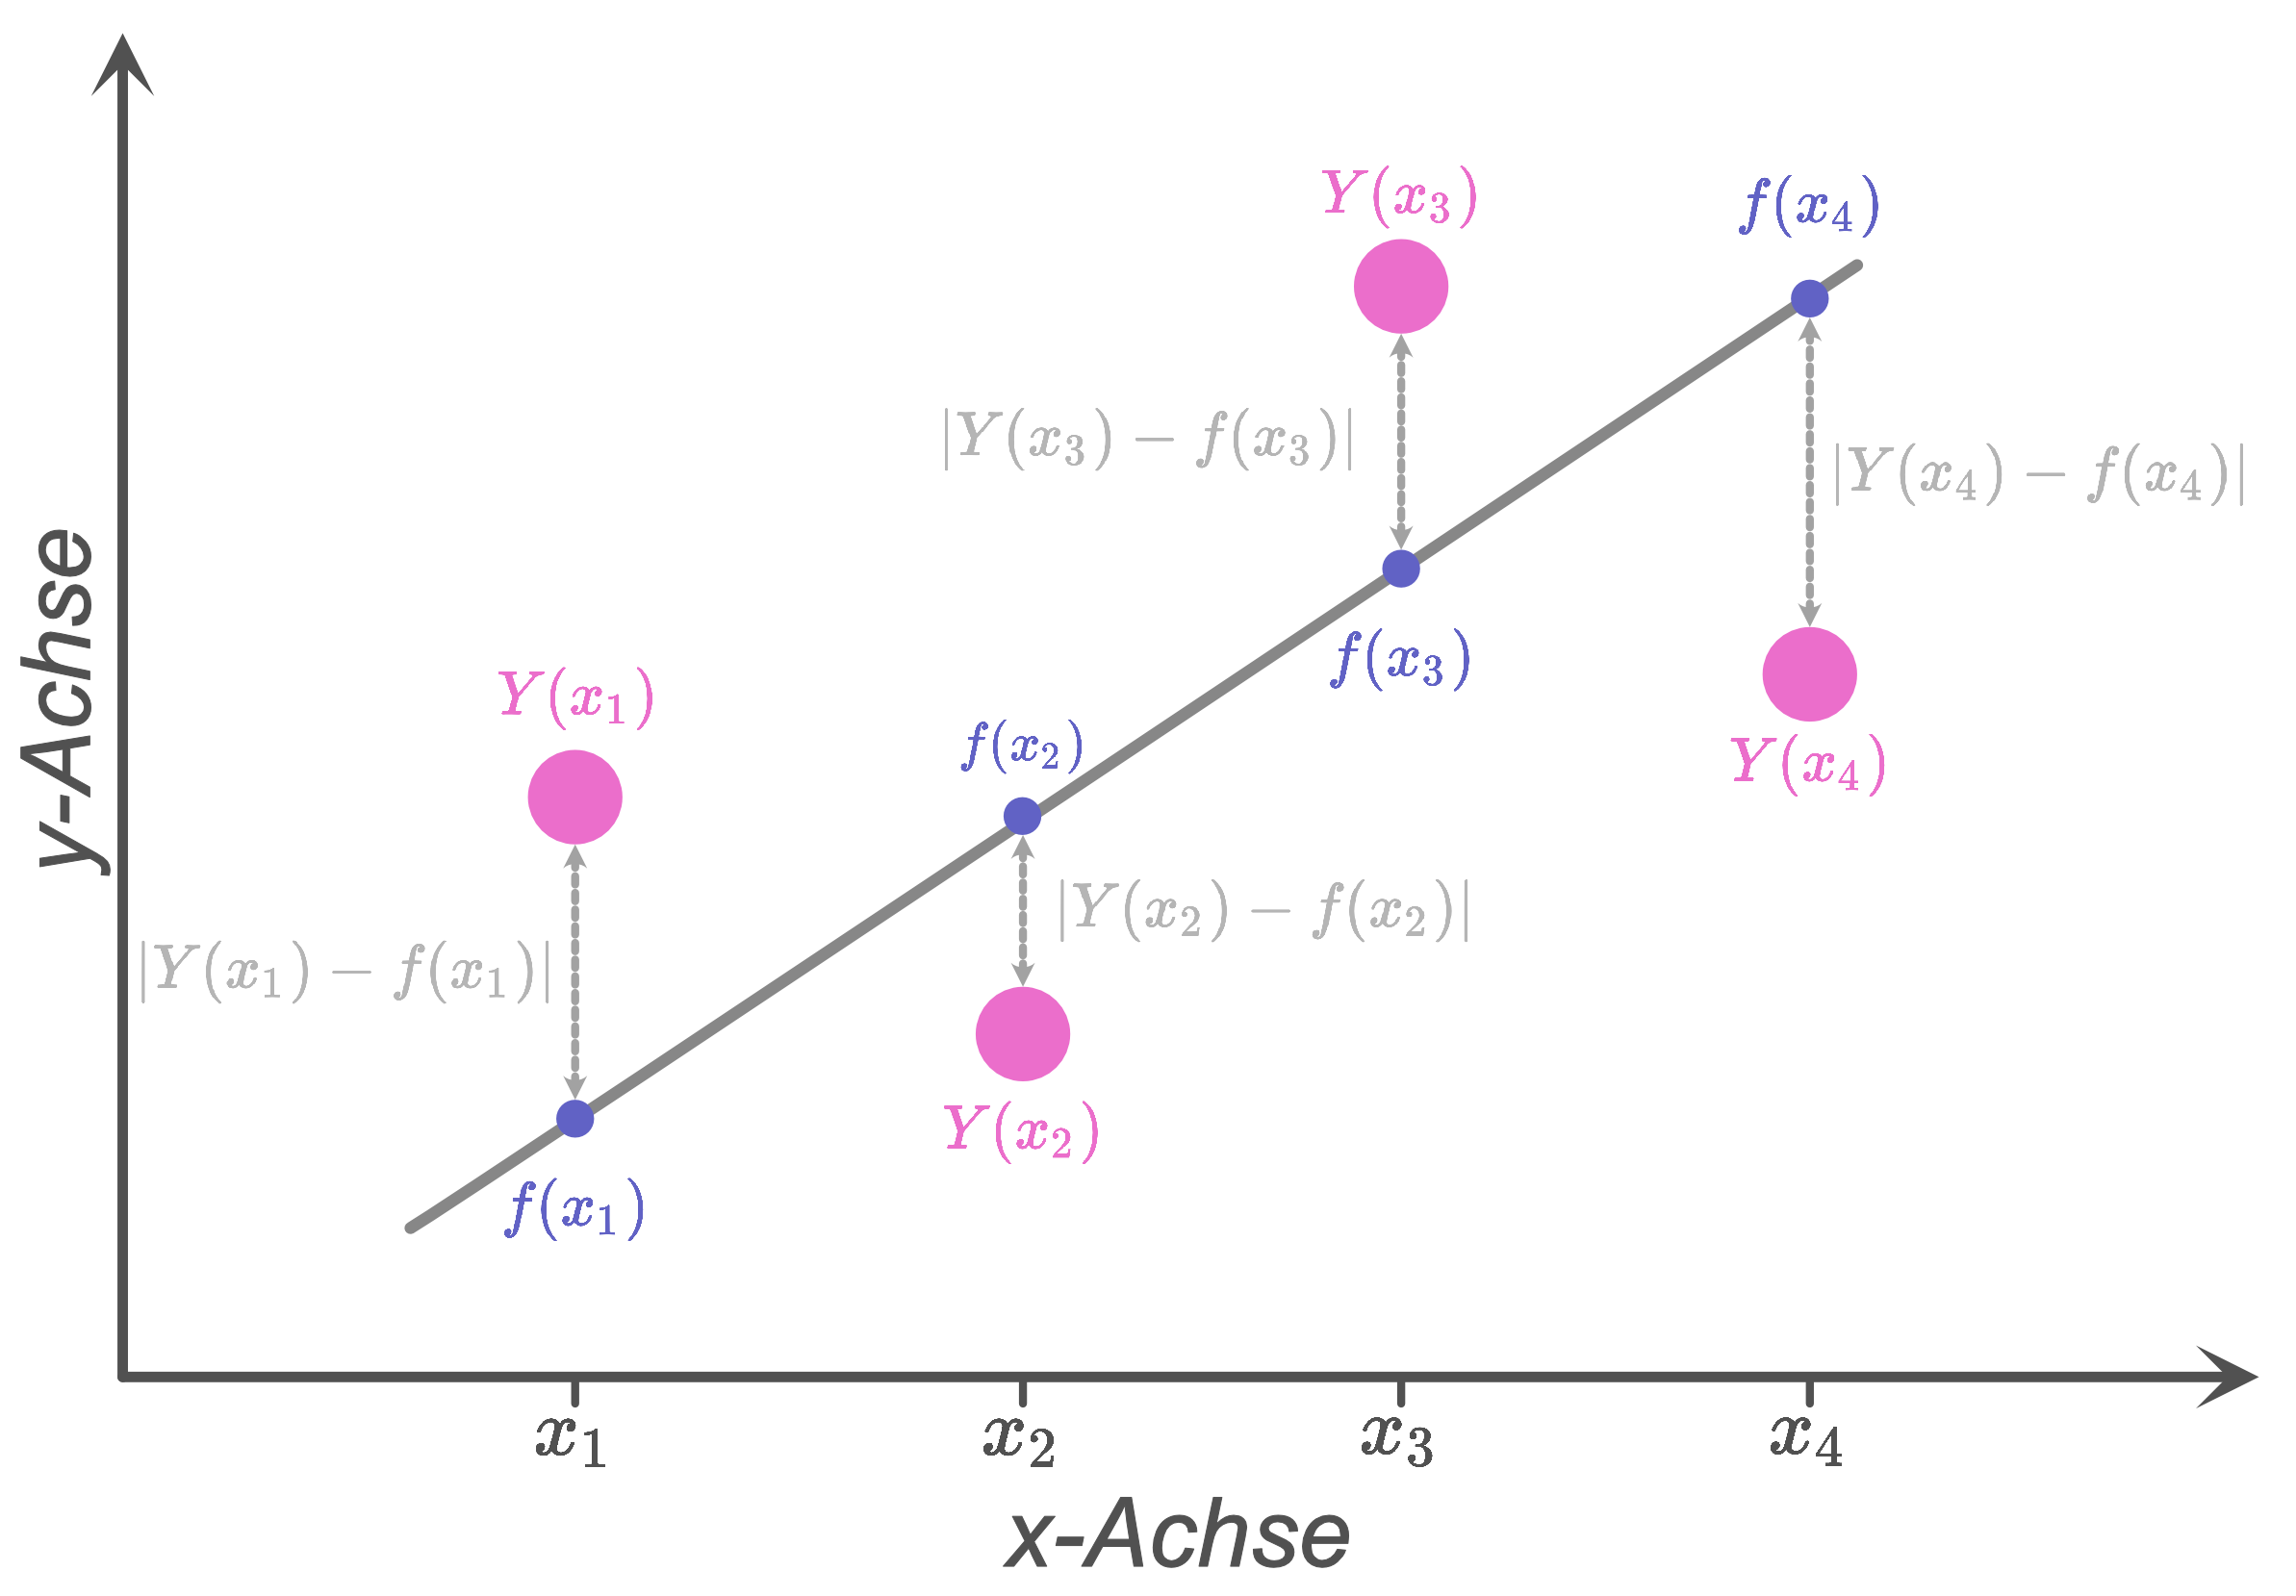

Grafisch kann man sich diese Abstände wie folgt vorstellen





 Let's say our actual data point is represented by $Y(x_1)$ and the predicted point is $f(x_1)$. The distance between them is $|Y(x_1) - f(x_1)|$.
 For all 4 points the average distance is calculated like this:
$$ \frac{1}{4} \big(|Y(x_1)-f(x_1)| + |Y(x_2)-f(x_2)| + |Y(x_3)-f(x_3)| + |Y(x_4)-f(x_4)|)
$$

So for N points the average distance is
$$
\frac{1}{N} \cdot \big(|Y(x_1)-f(x_1)| + |Y(x_2)-f(x_2)| + |Y(x_3)-f(x_3)| + ...+ |Y(x_n)-f(x_n)|)
$$



Je besser unsere Linie die Daten beschreibt, desto näher sollten die beiden ja aneinander sein und desto kleiner sollte dieser Wert werden.

The other way to calculate the error would be $\big(Y(x_1)-f(x_1)\big)^2$ for point $x_1$, than the general formula becomes:

$$
\frac{1}{N} \cdot \Big(\big(Y(x_1)-f(x_1)\big)^2 + \big(Y(x_2)-f(x_2)\big)^2 + \big(Y(x_3)-f(x_3)\big)^2 + ...\Big)
$$



In [ ]:
def mae_loss(y_true, y_pred):
  """
  Calculates the Mean Absolute Error (MAE) loss between two arrays.

  Args:
    y_true: The true values.
    y_pred: The predicted values.

  Returns:
    The MAE loss.
  """
  n = len(y_true)
  mae = 0
  for i in range(n):
    # mae += <Dein Code hier>/
    mae += abs(y_true[i] - y_pred[i])
    # solution: mae += abs(y_true[i] - y_pred[i])
  return mae / n

def mse_loss(y_true, y_pred):
  """
  Calculates the Mean Squared Error (MSE) loss between two arrays.

  Args:
    y_true: The true values.
    y_pred: The predicted values.

  Returns:
    The MSE loss.
  """
  n = len(y_true)
  mse = 0
  for i in range(n):
    # mse += <Dein Code hier>
    mse += (y_true[i] - y_pred[i])**2
    # solution: mse += (y_true[i] - y_pred[i])**2
  return mse / n

y_true = np.array([1, 2, 3, 4, 5])
y_pred = np.array([1.1, 1.9, 3.2, 3.8, 5.1])

mae = mae_loss(y_true, y_pred)
mse = mse_loss(y_true, y_pred)

# Tests
epsilon = 0.00001
assert abs(mse - 0.022) < epsilon, "Check your mse function"
assert abs(mae - 0.14) < epsilon, "Check your mae function"

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
# TODO: add tests, asserts, hints?

Mean Absolute Error (MAE): 0.14000000000000004
Mean Squared Error (MSE): 0.02200000000000002


MSE for line 1: 0.032199999999999986
MSE for line 2: 0.9470000000000003
MSE for line 3: 0.769
MAE for line 1: 0.14199999999999996
MAE for line 2: 0.8099999999999999
MAE for line 3: 0.6499999999999998


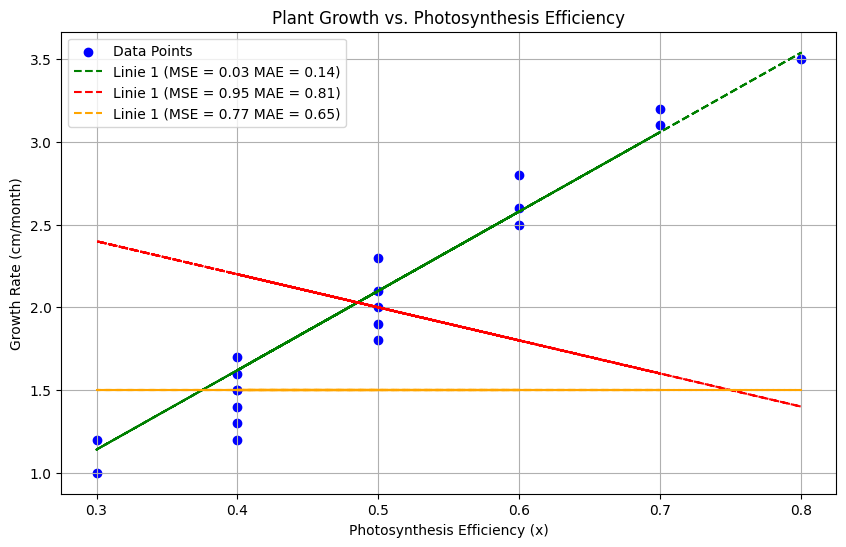

In [ ]:
# data with an outlier
\
x = np.array([plant[1] for plant in plants_data])
y = np.array([plant[2] for plant in plants_data])

# Calculating MAE and MSE for several given lines
linie_1 = lambda x: 4.8 * x - 0.3
linie_2 = lambda x: -2 * x + 3
linie_3 = lambda x: 1.5 + np.zeros_like(x)
# MSE
print(f"MSE for line 1: {mse_loss(y, linie_1(x))}")
print(f"MSE for line 2: {mse_loss(y, linie_2(x))}")
print(f"MSE for line 3: {mse_loss(y, linie_3(x))}")

# MAE
print(f"MAE for line 1: {mae_loss(y, linie_1(x))}")
print(f"MAE for line 2: {mae_loss(y, linie_2(x))}")
print(f"MAE for line 3: {mae_loss(y, linie_3(x))}")


# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data Points', color='blue')
plt.plot(x, linie_1(x), label=f'Linie 1 (MSE = {mse_loss(y, linie_1(x)):.2f} MAE = {mae_loss(y, linie_1(x)):.2f})', color='green', linestyle='--')
plt.plot(x, linie_2(x), label=f'Linie 1 (MSE = {mse_loss(y, linie_2(x)):.2f} MAE = {mae_loss(y, linie_2(x)):.2f})', color='red', linestyle='--')
plt.plot(x, linie_3(x), label=f'Linie 1 (MSE = {mse_loss(y, linie_3(x)):.2f} MAE = {mae_loss(y, linie_3(x)):.2f})', color='orange', linestyle='--')


plt.xlabel('Photosynthesis Efficiency (x)')
plt.ylabel('Growth Rate (cm/month)')
plt.title('Plant Growth vs. Photosynthesis Efficiency')
plt.legend()
plt.grid(True)
plt.show()

Think which line is the best approximation?
(Green). Which metrics is this conclusion based on (both). Disscuss if there were 2 lines with metrics mae better for one and mse better for other which would be the best solution and in which case?


MSE for line 1: 1.1097066666666666
MSE for line 2: 1.1652380952380952
MSE for line 3: 1.352767857142857
MAE for line 1: 0.6121904761904762
MAE for line 2: 0.5857142857142857
MAE for line 3: 0.5773809523809523


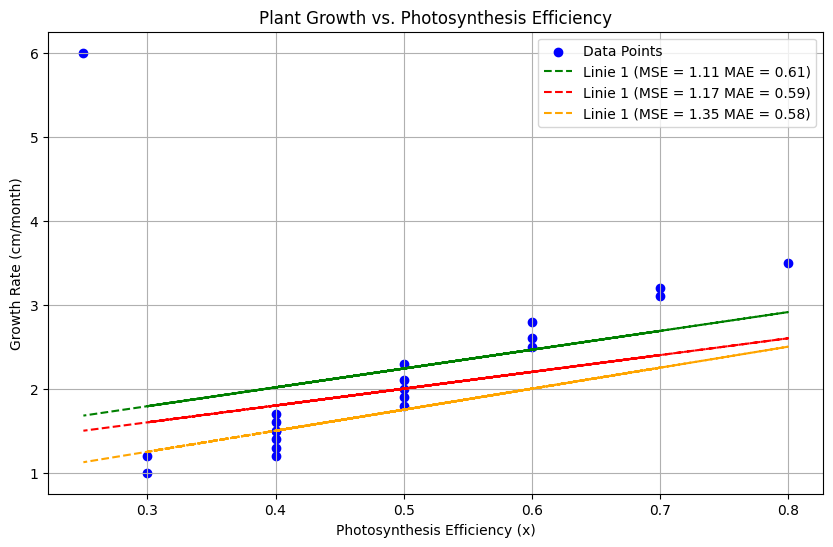

*Welche Loss-Funktion ist in dein Meinung nach empfindlicher gegenüber Ausreißern? Warum?*

\<Dein antwort hier>

### Aufgabe 6.1.3 <span style="color: #C26BCA;"> Automatisierung </span>
Diese Parametersuche ist sehr aufwändig. Unser Datensatz ist ja noch relativ einfach gewesen... Aber wie gehen wir am besten bei komplexeren Datensätzen vor? Hier kommt *künstliche Intelligenz* ins Spiel! Es gibt nämlich sehr nützliche Algorithmen, die selbstständig die Parametersuche ausführen können. Im Grunde funktionieren sie genauso wie in der vorherigen Aufgabe: Sie suchen die Parameter, indem sie versuchen, den MSE Wert zu minimieren!

Dazu benutzen wir die Klasse `LinearRegression` von dem Paket Scikit-learn:

In [ ]:
from sklearn.linear_model import LinearRegression

Eine Klasse ist ein Teil eines Moduls in Python, der es erlaubt, neue Objekte zu erstellen. In unserem Fall wollen wir damit ein Modell definieren:

In [ ]:
modell = LinearRegression(fit_intercept=True)

Der Parameter `fit_intercept` spezifiziert, dass wir nicht nur die Steigung $m$ in $f(x)=m\cdot x+c$, sondern auch den y-Achsenabschnitt $c$. Wir werden hier einen beliebigen Datensatz verwenden, den wir auch oben verwendet haben. In diesem Beispiel war es nämlich nicht ganz so eindeutig, welche Fitgerade die richtige war:

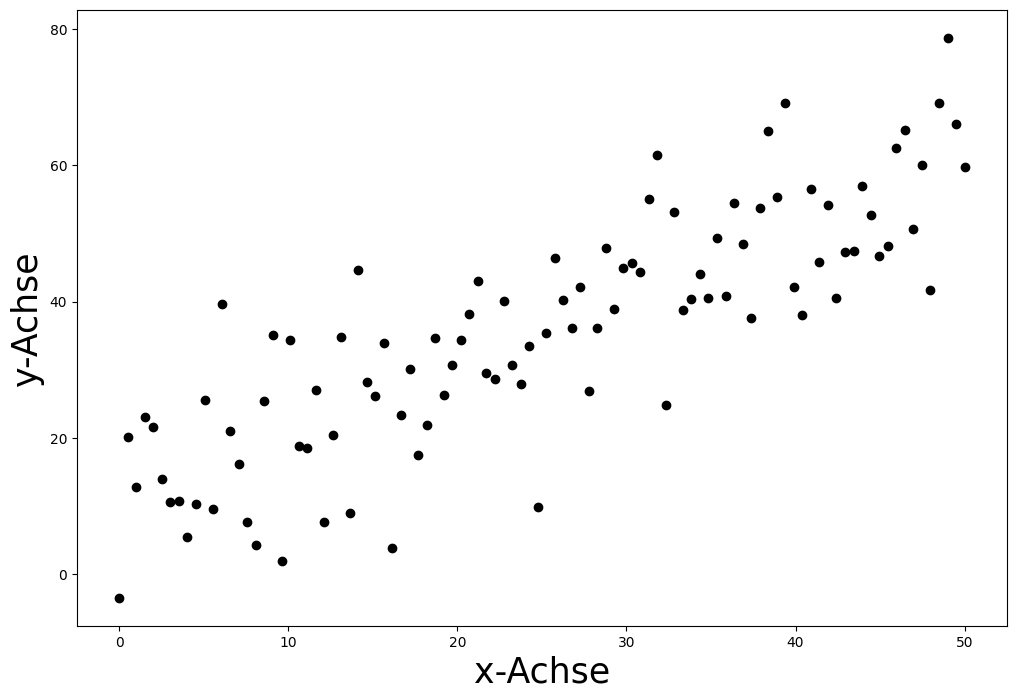

In [ ]:
# TODO: we could formulate a finacial example here instead
x = np.array([0.0, 0.51, 1.01, 1.52, 2.02, 2.53, 3.03, 3.54, 4.04, 4.55, 5.05, 5.56, 6.06, 6.57, 7.07, 7.58, 8.08, 8.59, 9.09, 9.6, 10.1, 10.61, 11.11, 11.62, 12.12, 12.63, 13.13, 13.64, 14.14, 14.65, 15.15, 15.66, 16.16, 16.67, 17.17, 17.68, 18.18, 18.69, 19.19, 19.7, 20.2, 20.71, 21.21, 21.72, 22.22, 22.73, 23.23, 23.74, 24.24, 24.75, 25.25, 25.76, 26.26, 26.77, 27.27, 27.78, 28.28, 28.79, 29.29, 29.8, 30.3, 30.81, 31.31, 31.82, 32.32, 32.83, 33.33, 33.84, 34.34, 34.85, 35.35, 35.86, 36.36, 36.87, 37.37, 37.88, 38.38, 38.89, 39.39, 39.9, 40.4, 40.91, 41.41, 41.92, 42.42, 42.93, 43.43, 43.94, 44.44, 44.95, 45.45, 45.96, 46.46, 46.97, 47.47, 47.98, 48.48, 48.99, 49.49, 50.0])
y = np.array([-3.48, 20.17, 12.78, 23.06, 21.52, 13.94, 10.56, 10.65, 5.38, 10.21, 25.59, 9.61, 39.67, 21.02, 16.13, 7.6, 4.33, 25.42, 35.1, 1.88, 34.31, 18.73, 18.51, 26.95, 7.58, 20.37, 34.78, 8.97, 44.6, 28.24, 26.14, 33.99, 3.82, 23.37, 30.17, 17.5, 21.82, 34.72, 26.28, 30.62, 34.4, 38.22, 43.02, 29.48, 28.63, 40.06, 30.67, 27.94, 33.43, 9.84, 35.35, 46.46, 40.22, 36.08, 42.13, 26.82, 36.05, 47.85, 38.97, 44.88, 45.72, 44.38, 55.0, 61.47, 24.86, 53.09, 38.8, 40.35, 44.04, 40.58, 49.35, 40.79, 54.52, 48.46, 37.59, 53.79, 65.09, 55.38, 69.11, 42.07, 38.07, 56.58, 45.87, 54.19, 40.56, 47.22, 47.46, 56.92, 52.75, 46.69, 48.16, 62.51, 65.22, 50.7, 60.1, 41.77, 69.17, 78.74, 66.13, 59.73])

# TODO: make the plot a bit preatier
plt.figure(figsize=(12,8))
plt.scatter(x,y, color='black')
plt.xlabel('x-Achse', fontsize=25)
plt.ylabel('y-Achse', fontsize=25)
plt.show()

Das Modell kann dann mit `.fit` an diese Daten angepasst werden. Hier muss beachtet werden, dass die x-Werte für die Nutzung in diesem Paket in eine andere Form mit `.reshape()` gebracht werden müssen. Die Daten bleiben dabei aber dieselben:

In [ ]:
trainiertes_modell = modell.fit(x.reshape(-1, 1), y)

Haben wir nun einen neuen Datenpunkt, also wollen wir zum Beispiel wissen, welcher y-Wert bei x-Wert 20 herauskommt, so können wir `.predict()` nutzen:

In [ ]:
x_wert = 20
vorhersage = trainiertes_modell.predict(np.array(x_wert).reshape(-1, 1))

print('Bei x-Wert',x_wert,'erwarten wir den y-Wert', round(vorhersage[0],2))

Bei x-Wert 20 erwarten wir den y-Wert 30.64


Diese Funktion können wir dann ausnutzen, um uns den linearen Fit tatsächlich anzeigen zu lassen:

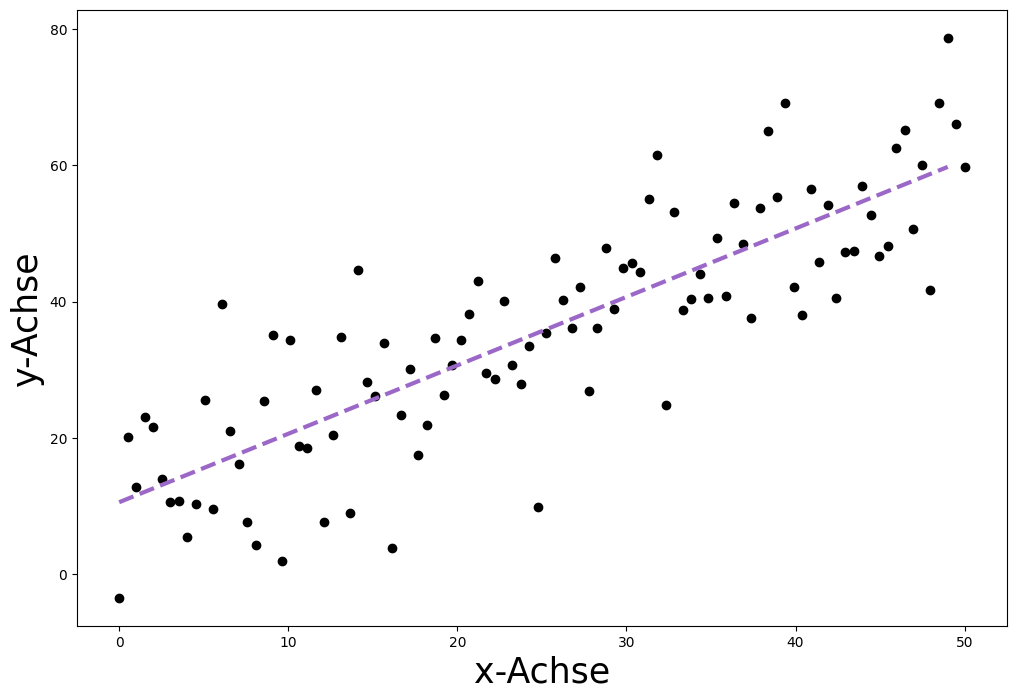

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(x,y, color='black')

x_werte = np.arange(min(x), max(x))
y_werte = trainiertes_modell.predict(x_werte.reshape(-1, 1))
plt.plot(x_werte,y_werte, color='#9C68C8', ls='--',lw=3)

plt.xlabel('x-Achse', fontsize=25)
plt.ylabel('y-Achse', fontsize=25)
plt.show()

Wir können auch die Parameter $m$ und $c$ ausgeben lassen:

In [ ]:
m_fitted = trainiertes_modell.coef_[0]    # Steigung
c_fitted = trainiertes_modell.intercept_  # y-Achsenabschnitt

print('Steigung m =', round(m_fitted,2))
print('y-Achsenabschnitt c =', round(c_fitted,2))

Steigung m = 1.0
y-Achsenabschnitt c = 10.54


### Aufgabe 6.1.4 <span style="color: #C26BCA;"> Ausreißer </span>
*Ein Ausreißer ist ein Datenpunkt, der sich deutlich von anderen Beobachtungen in einem Datensatz unterscheidet. Solche Punkte können aufgrund von Messfehlern, außergewöhnlichen Umständen oder natürlichen Abweichungen auftreten.

Ausreißer, wie zum Beispiel eine gigantische, leuchtende Pflanze, können die lineare Regression erheblich beeinflussen:

  * Verschiebung der Linie: Der Ausreißer, als extremer Datenpunkt, zieht die Regressionslinie nach oben. Die Linie versucht, diese ungewöhnliche Beobachtung einzubeziehen, was zu einer steileren Steigung und einem höheren Achsenabschnitt führt, als dies ohne den Ausreißer der Fall wäre.

  * Reduzierte Genauigkeit: Durch die Anpassung an den Ausreißer wird die Regressionslinie weniger genau bei der Vorhersage der Höhe typischer Pflanzen. Das Modell überschätzt die Höhe für Pflanzen mit geringer Sonnenlichtexposition und unterschätzt die Höhe für Pflanzen mit hoher Sonnenlichtexposition.

  * Verzerrte Darstellung der Beziehung: Der Ausreißer verfälscht die Darstellung der Beziehung zwischen Sonnenlicht und Pflanzenhöhe. Die Beziehung erscheint dadurch stärker und linearer, als sie für den Großteil der Pflanzen tatsächlich ist.

Unten sehen Sie ein Beispiel, was passiert, wenn wir selbst nur ein einziges ungewöhnliches Experimentergebnis hinzufügen.*

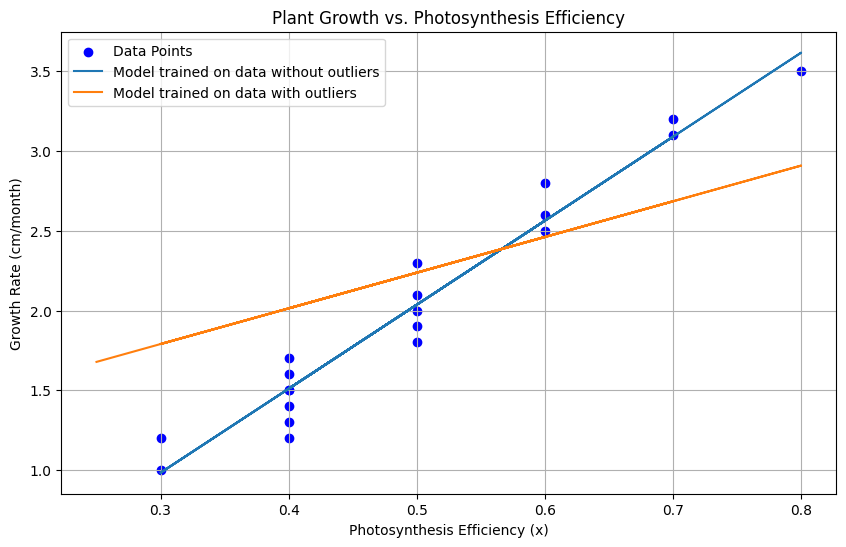

In [ ]:
# ordinary data
x = np.array([plant[1] for plant in plants_data])
y = np.array([plant[2] for plant in plants_data])

# data with an outlier
plants_data_with_outlier = plants_data + [["Some very strange plant", 0.25, 6]]
x_with_outlier = np.array([plant[1] for plant in plants_data_with_outlier])
y_with_outlier = np.array([plant[2] for plant in plants_data_with_outlier])


modell = LinearRegression(fit_intercept=True)
trainiertes_modell = modell.fit(x.reshape(-1, 1), y)
modell = LinearRegression(fit_intercept=True)
trainiertes_modell_with_outlier = modell.fit(x_with_outlier.reshape(-1, 1), y_with_outlier)



# Calculating MAE and MSE for several given lines

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data Points', color='blue')
plt.plot(x, trainiertes_modell.predict(x.reshape(-1, 1)), label="Model trained on data without outliers")
plt.plot(x_with_outlier, trainiertes_modell_with_outlier.predict(x_with_outlier.reshape(-1, 1)), label="Model trained on data with outliers")
plt.xlabel('Photosynthesis Efficiency (x)')
plt.ylabel('Growth Rate (cm/month)')
plt.title('Plant Growth vs. Photosynthesis Efficiency')
plt.legend()
plt.grid(True)
plt.show()

### <span style="color: #EB6ECB;">Aufgabe 6.1.5</span>
 *Jetzt bist du dran! Nutze deine neu erlernten Fähigkeiten, um eine Gerade an unsere Daten zu fitten. Nutze Matplotlib, um die Linie zu dem Plot hinzuzufügen. Gib dann die Steigung $m$ und den y-Achsenabschnitt des Modells aus.*

In [ ]:
<Dein Code hier>

Slope (m): 2.2377049180327875
Intercept (c): 1.1184426229508195


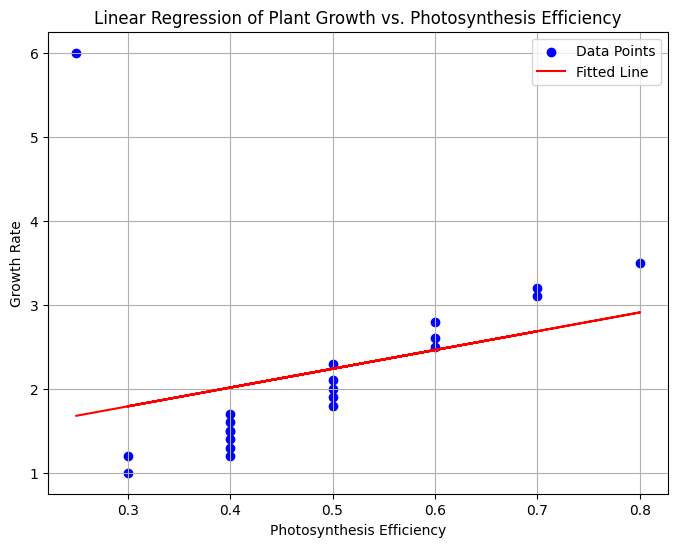

In [ ]:
# Solution

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression # !! they have to use sklearn

# Create and fit the linear regression model
model = LinearRegression()
x_reshaped = x.reshape(-1, 1)  # Reshape x for sklearn
model.fit(x_reshaped, y)

# Make predictions
y_pred = model.predict(x_reshaped)

# Print the coefficients (slope and intercept)
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)


# Plot the data and the fitted line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label="Data Points", color='blue')
plt.plot(x, y_pred, color="red", label="Fitted Line")  # Plot the fitted line
plt.xlabel("Photosynthesis Efficiency")
plt.ylabel("Growth Rate (cm/month)")
plt.title("Linear Regression of Plant Growth vs. Photosynthesis Efficiency")
plt.legend()
plt.grid(True)
plt.show()

### Hinweis
 Sei vorsichtig bei der Anwendung der linearen Regression - sie ist nicht immer die beste Wahl. Es ist entscheidend, die Daten zunächst zu visualisieren und zu analysieren, um ihre Struktur zu verstehen. Wenn die Datenpunkte beispielsweise ein kreisförmiges Muster bilden, könnte eine gerade Linie zwar den Abstand zu allen Punkten minimieren, aber die Beziehung nicht effektiv erfassen, was sie zu einem schlechten prädiktiven Modell macht.

best line formula 0.023961964857488277 x + 0.007818365669565498


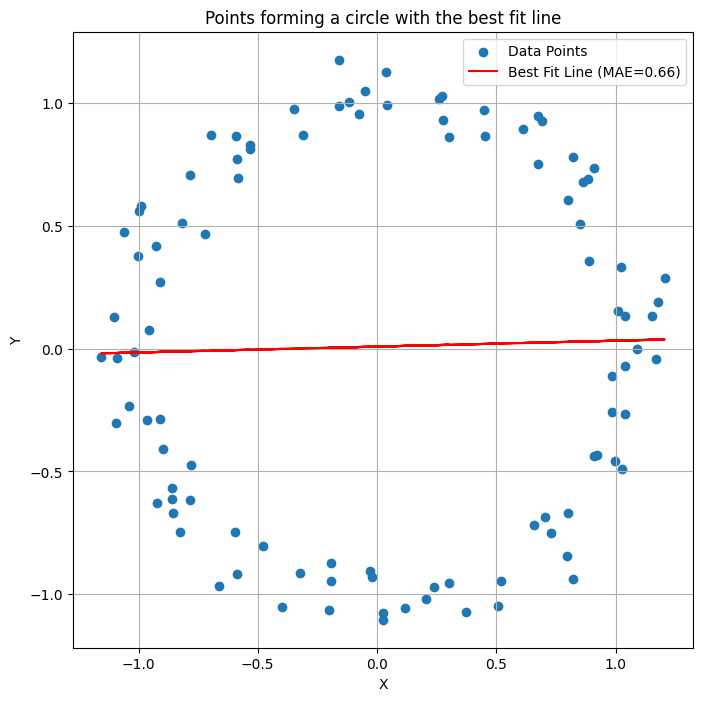

In [ ]:
# The following code is only for the sake of showing contrexample plot. There is no need to undersand.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

# Generates points almost forming a circle
np.random.seed(0)
n_points = 100
angles = np.linspace(0, 2 * np.pi, n_points)
radius = 1
noise = 0.1
x = radius * np.cos(angles) + noise * np.random.randn(n_points)
y = radius * np.sin(angles) + noise * np.random.randn(n_points)

# # Find the line that minimizes MAE
# best_mae = float('inf')
# best_line = None

# could include it before automatization?
# for m in np.linspace(-2, 2, 100):
#     for c in np.linspace(-2, 2, 100):
#       predicted_y = m * x + c
#       mae = mean_absolute_error(y, predicted_y)
#       if mae < best_mae:
#           best_mae = mae
#           best_line = (m, c)

# Create and fit the linear regression model
modell = LinearRegression(fit_intercept=True)
trainiertes_modell = modell.fit(x.reshape(-1, 1), y)
y_pred = trainiertes_modell.predict(x.reshape(-1, 1))
best_mae = mean_absolute_error(y, y_pred)
best_line = (trainiertes_modell.coef_[0], trainiertes_modell.intercept_)
print(f"best line formula {trainiertes_modell.coef_[0]} x + {trainiertes_modell.intercept_}")
#Plot results

plt.figure(figsize=(8, 8))
plt.scatter(x, y, label="Data Points")
plt.plot(x, y_pred, color='red', label=f"Best Fit Line (MAE={best_mae:.2f})")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Points forming a circle with the best fit line")
plt.legend()
plt.grid(True)
plt.show()

### Bonusaufgabe
1. *Wenn du dich dafür interessierst, wie ähnliche Experimente durchgeführt werden, und selbst einen Einstieg in die Botanik wagen möchten, finden Sie hier ein [Tutorial](https://www.wikihow.com/Measure-Growth-Rate-of-Plants), das erklärt, wie man die Wachstumsrate von Pflanzen messen kann.*

2. Do you know how the lack of gravity affects plans, here is an article about plant growing on a scace statin https://slate.com/human-interest/2014/09/how-do-plants-grow-aboard-the-international-space-station.html

3. Try using different argument for kernel  the possible values are ‘linear’, ‘poly’, ‘rbf’. Which one approximates best given points?

Solution: rbf

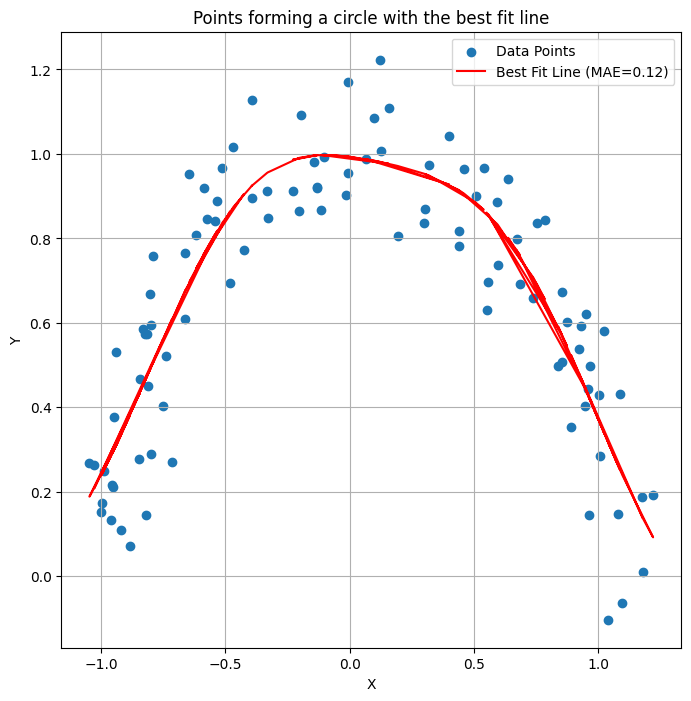

In [ ]:
# The following code is only for the sake of showing contrexample plot. There is no need to undersand.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR

# Generates points almost forming a circle
np.random.seed(0)
n_points = 100
angles = np.linspace(0, np.pi, n_points)
radius = 1
noise = 0.1
x = radius * np.cos(angles) + noise * np.random.randn(n_points)
y = radius * np.sin(angles) + noise * np.random.randn(n_points)

# Create and fit the linear regression model
modell = SVR(kernel=<your code here>)
# modell = SVR(kernel="rbf")
# modell = SVR(kernel="linear")
# modell = SVR(kernel="poly")

trainiertes_modell = modell.fit(x.reshape(-1, 1), y)
y_pred = trainiertes_modell.predict(x.reshape(-1, 1))
best_mae = mean_absolute_error(y, y_pred)
#Plot results

plt.figure(figsize=(8, 8))
plt.scatter(x, y, label="Data Points")
plt.plot(x, y_pred, color='red', label=f"Best Fit Line (MAE={best_mae:.2f})")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Points forming a circle with the best fit line")
plt.legend()
plt.grid(True)
plt.show()